# 04 — Model Evaluation & Explainability

**Goal:** Evaluate the final XGBoost model on the held-out test set (touched
for the first time), produce SHAP explanations at global and individual level,
and translate results into a business-readable summary.

**This notebook contains:**
1. Final test set evaluation (AUC-ROC, confusion matrix, classification report)
2. Precision-recall curve and optimal threshold analysis
3. SHAP global feature importance (summary plot)
4. SHAP local explanation (waterfall plot for one customer)
5. Business impact quantification
6. Non-technical one-page summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import joblib
import shap

from sklearn.metrics import (roc_auc_score, 
                             roc_curve, 
                             confusion_matrix, 
                             classification_report,
                             precision_recall_curve, 
                             average_precision_score,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

print("Libraries loaded.")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
# Load processed data
X_train = np.load("../data/processed/X_train.npy")
X_val   = np.load("../data/processed/X_val.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_val   = np.load("../data/processed/y_val.npy")
y_test  = np.load("../data/processed/y_test.npy")

# Load fitted preprocessor (to get feature names)
preprocessor = joblib.load("../models/preprocessor.pkl")

# Load final trained model
model = joblib.load("../models/xgb_churn_model.pkl")

print("All assets loaded.")
print(f"Test set: {X_test.shape[0]} customers")

All assets loaded.
Test set: 1409 customers


In [3]:
# Numeric and binary feature names (same order as Phase 3)
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
binary_features  = ["gender", "SeniorCitizen", "Partner", "Dependents",
                    "PhoneService", "PaperlessBilling"]

# Categorical feature names after OneHotEncoding
categorical_features = ["MultipleLines", "InternetService", 
                        "OnlineSecurity","OnlineBackup", 
                        "DeviceProtection", "TechSupport",
                        "StreamingTV", "StreamingMovies", 
                        "Contract","PaymentMethod", "tenure_bin"]

ohe_feature_names = (preprocessor
                     .named_transformers_["cat"]["encoder"]
                     .get_feature_names_out(categorical_features))

all_feature_names = numeric_features + binary_features + list(ohe_feature_names)

print(f"Total features: {len(all_feature_names)}")

Total features: 43


## The test set — touching it for the first time

Everything done in Phase 3 and Phase 4 (preprocessing, model selection,
hyperparameter choices, threshold setting) was done using training and
validation data only. The test set was set aside and never consulted.

**This matters because:** any decision made while looking at test performance
subtly optimises for the test set. If you tune hyperparameters on the test
set, you are effectively training on it — and the final score will be
overoptimistic, not representative of real-world performance.

The score we report from this notebook is the number that goes in the README,
the model card, and on the portfolio. It is the honest, trustworthy estimate.

####  ROC curve

In [4]:
# Probability of churn for each test customer (number between 0 and 1)
test_probs = model.predict_proba(X_test)[:, 1]

# Hard predictions using the 0.4 threshold committed to in Phase 1
test_preds = (test_probs >= 0.4).astype(int)

# AUC-ROC does not depend on threshold — computed on raw probabilities
test_auc = roc_auc_score(y_test, test_probs)

print(f"Test set AUC-ROC: {test_auc:.4f}")
print(f"\nAt threshold 0.4:")
print(f"  Predicted churn:    {test_preds.sum()} customers")
print(f"  Actual churn:       {y_test.sum().astype(int)} customers")

Test set AUC-ROC: 0.8362

At threshold 0.4:
  Predicted churn:    616 customers
  Actual churn:       374 customers


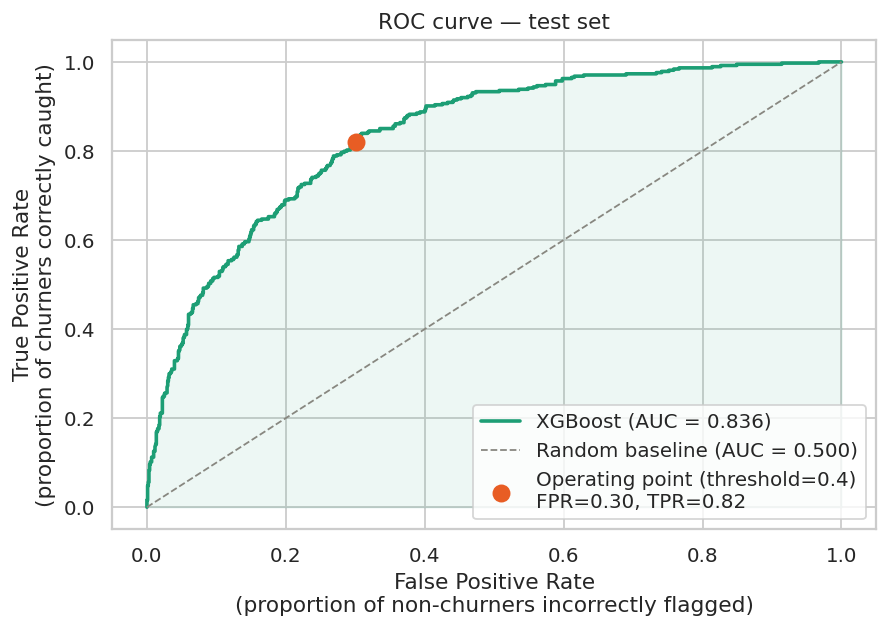

In [5]:
fpr, tpr, thresholds_roc = roc_curve(y_test, test_probs)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color="#1D9E75", linewidth=2,
        label=f"XGBoost (AUC = {test_auc:.3f})")
ax.plot([0, 1], [0, 1], color="#888780", linewidth=1,
        linestyle="--", label="Random baseline (AUC = 0.500)")

ax.fill_between(fpr, tpr, alpha=0.08, color="#1D9E75")
ax.set_xlabel("False Positive Rate\n(proportion of non-churners incorrectly flagged)")
ax.set_ylabel("True Positive Rate\n(proportion of churners correctly caught)")
ax.set_title("ROC curve — test set")
ax.legend(loc="lower right")

# Mark the operating point at threshold 0.4
idx = np.argmin(np.abs(thresholds_roc - 0.4))
ax.scatter(fpr[idx], tpr[idx], color="#E85D24", zorder=5, s=80,
           label=f"Operating point (threshold=0.4)\nFPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f}")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../docs/figures/07_roc_curve.png", bbox_inches="tight")
plt.show()

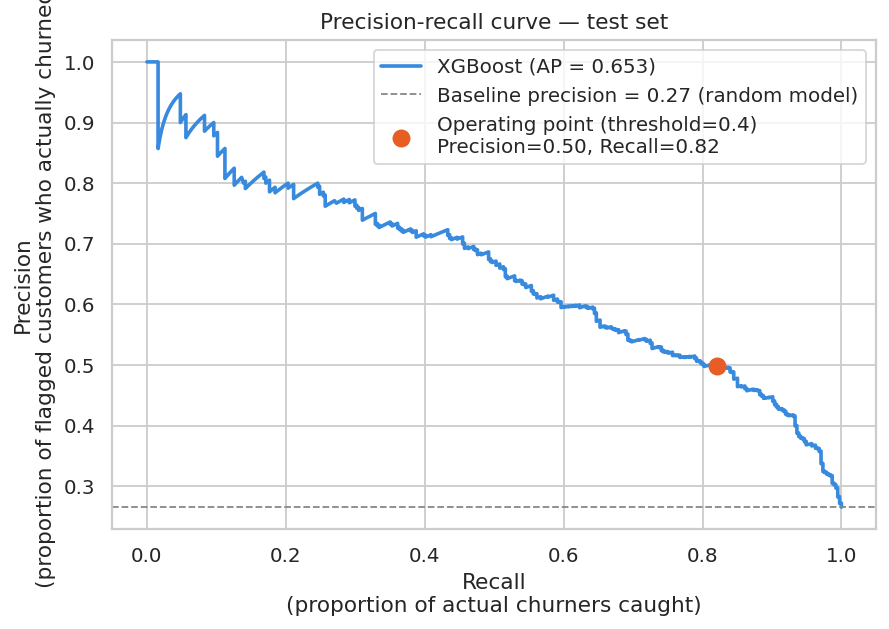

In [6]:
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, test_probs)
avg_precision = average_precision_score(y_test, test_probs)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(recall_curve, precision_curve, color="#378ADD", linewidth=2,
        label=f"XGBoost (AP = {avg_precision:.3f})")
ax.axhline(y_test.mean(), color="#888780", linestyle="--", linewidth=1,
           label=f"Baseline precision = {y_test.mean():.2f} (random model)")

# Mark operating point
idx_pr = np.argmin(np.abs(thresholds_pr - 0.4))
ax.scatter(recall_curve[idx_pr], precision_curve[idx_pr],
           color="#E85D24", zorder=5, s=80,
           label=f"Operating point (threshold=0.4)\nPrecision={precision_curve[idx_pr]:.2f}, Recall={recall_curve[idx_pr]:.2f}")

ax.set_xlabel("Recall\n(proportion of actual churners caught)")
ax.set_ylabel("Precision\n(proportion of flagged customers who actually churned)")
ax.set_title("Precision-recall curve — test set")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../docs/figures/08_precision_recall_curve.png", bbox_inches="tight")
plt.show()

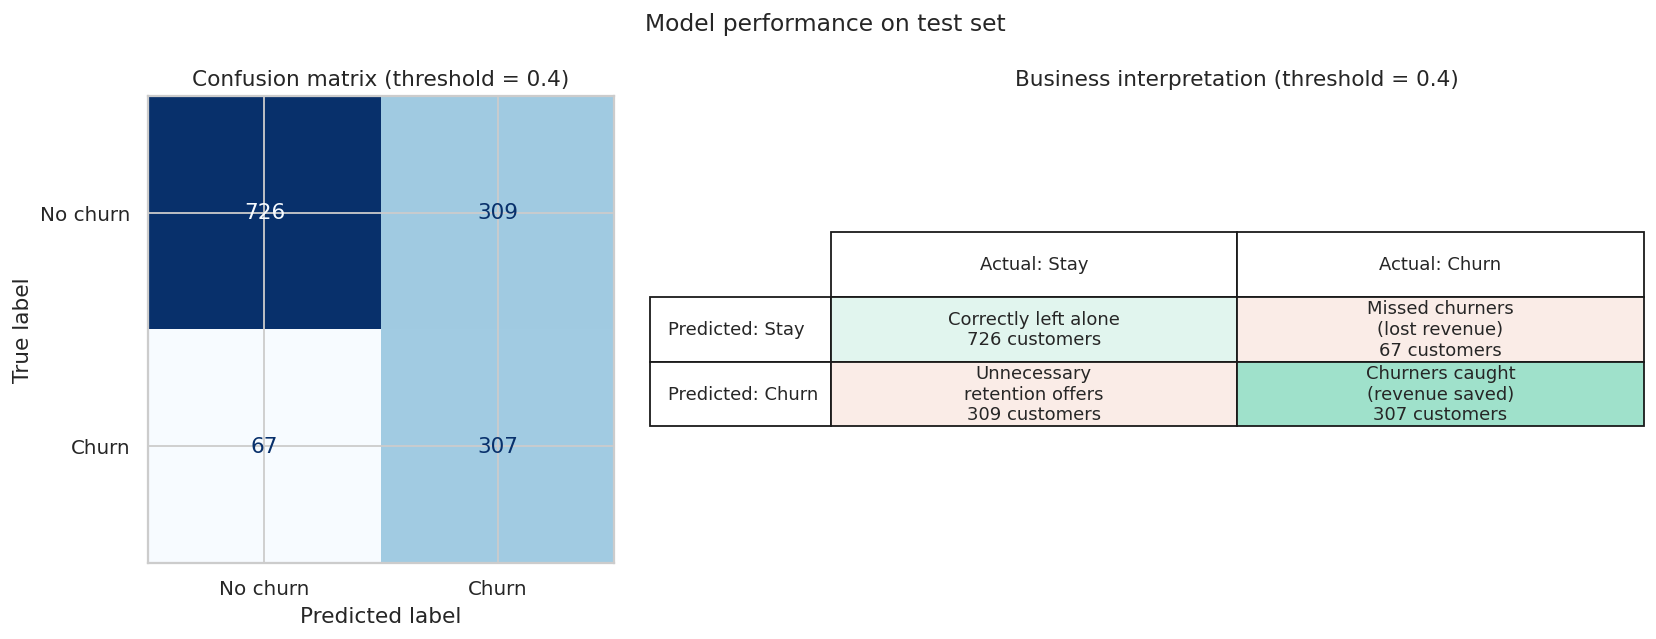


True Negatives  (correctly left alone):     726
False Positives (unnecessary offers sent):  309
False Negatives (churners missed):          67
True Positives  (churners caught):          307

Recall (% churners caught):     82.1%
Precision (% of flags correct): 49.8%


In [ ]:
cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: standard confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No churn", "Churn"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (threshold = 0.4)")

# Right: business framing version
business_labels = np.array([[f"Correctly left alone\n{tn} customers",
                             f"Missed churners\n(lost revenue)\n{fn} customers"],
                            [f"Unnecessary\nretention offers\n{fp} customers",
                             f"Churners caught\n(revenue saved)\n{tp} customers"]])

axes[1].axis("off")
table = axes[1].table(cellText=business_labels,
                      rowLabels=["Predicted: Stay", "Predicted: Churn"],
                      colLabels=["Actual: Stay", "Actual: Churn"],
                      cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.4, 3.2)

# Color cells
table[(1, 0)].set_facecolor("#E1F5EE")  # TN — light green
table[(1, 1)].set_facecolor("#FAECE7")  # FN — light red
table[(2, 0)].set_facecolor("#FAECE7")  # FP — light red
table[(2, 1)].set_facecolor("#9FE1CB")  # TP — strong green

axes[1].set_title("Business interpretation (threshold = 0.4)")

plt.suptitle("Model performance on test set", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/figures/09_confusion_matrix.png", bbox_inches="tight")
plt.show()

print(f"\nTrue Negatives  (correctly left alone):     {tn}")
print(f"False Positives (unnecessary offers sent):  {fp}")
print(f"False Negatives (churners missed):          {fn}")
print(f"True Positives  (churners caught):          {tp}")
print(f"\nRecall (% churners caught):     {tp/(tp+fn)*100:.1f}%")
print(f"Precision (% of flags correct): {tp/(tp+fp)*100:.1f}%")

In [8]:
print("Classification Report — Test Set (threshold = 0.4)\n")
print(classification_report(y_test, test_preds,
                             target_names=["No churn", "Churn"]))

Classification Report — Test Set (threshold = 0.4)

              precision    recall  f1-score   support

    No churn       0.92      0.70      0.79      1035
       Churn       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



## SHAP Explainability

The model now produces accurate predictions. But a prediction alone is not
actionable. The retention team needs to know:

- *Which features drove this customer's high churn probability?*
- *Is it their contract type? Their monthly charges? Their tenure?*

Without this, a retention manager sees "Customer X: 87% churn risk" and
has no idea whether to offer a discount, a contract upgrade, or a call from
a customer success manager.

**SHAP (SHapley Additive Explanations)** answers this. It computes, for
every single prediction, how much each feature pushed the prediction above
or below the average model output. Features that increase churn probability
get positive SHAP values. Features that decrease it get negative SHAP values.
The sum of all SHAP values for a customer equals the difference between their
predicted probability and the dataset average.

**This is based on Shapley values from cooperative game theory.** The idea:
treat features as "players" in a game whose "payout" is the prediction.
Shapley values fairly distribute credit among players based on their marginal
contribution across all possible orderings of features entering the model.
This mathematical guarantee of fairness is why SHAP is the industry standard.

In [9]:
# TreeExplainer is optimised specifically for tree-based models like XGBoost
# It is exact (not approximate) and very fast for these model types
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the test set
# This may take 30-60 seconds depending on your machine
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed.")
print(f"Shape: {shap_values.shape}  (one value per customer per feature)")
print(f"       {X_test.shape[0]} customers × {X_test.shape[1]} features")

SHAP values computed.
Shape: (1409, 43)  (one value per customer per feature)
       1409 customers × 43 features


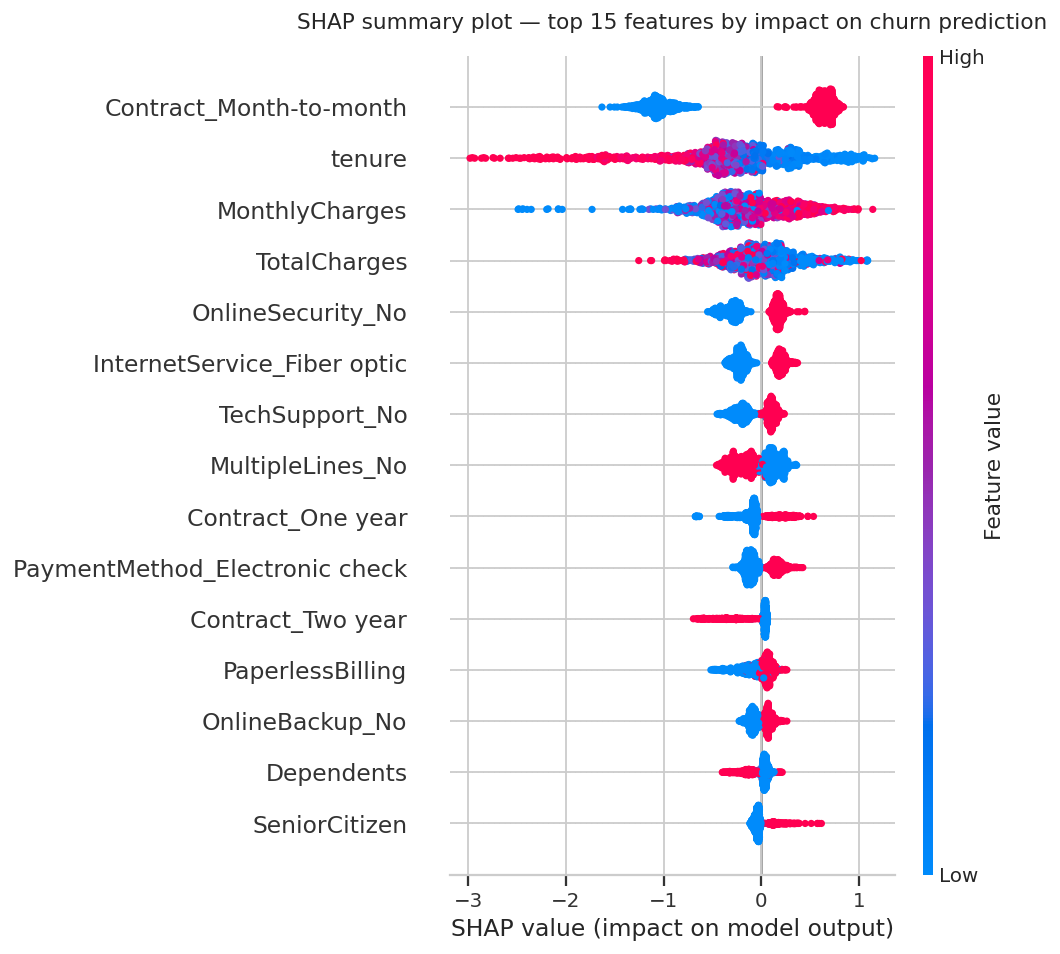

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(shap_values,
                  X_test,
                  feature_names=all_feature_names,
                  max_display=15,
                  show=False)

plt.title("SHAP summary plot — top 15 features by impact on churn prediction",
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../docs/figures/10_shap_summary.png", bbox_inches="tight")
plt.show()

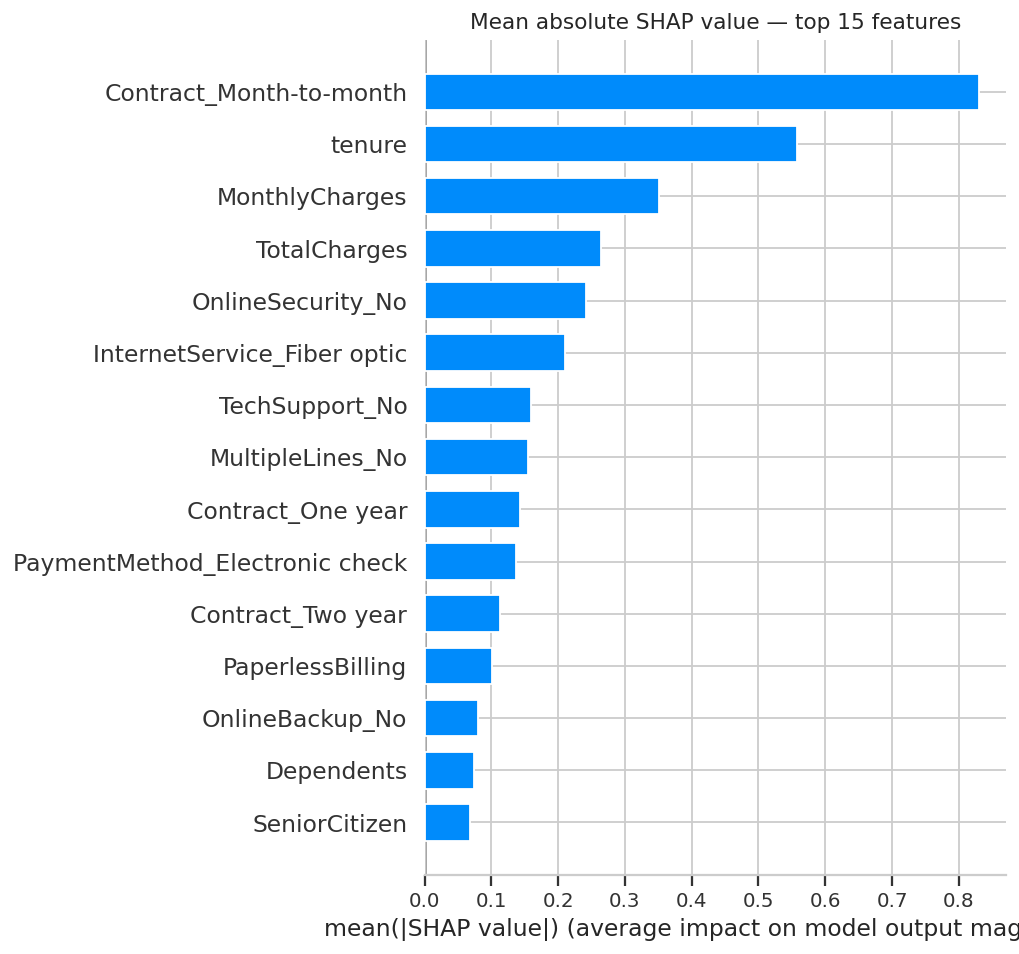

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

shap.summary_plot(shap_values,
                  X_test,
                  feature_names=all_feature_names,
                  plot_type="bar",
                  max_display=15,
                  show=False)

plt.title("Mean absolute SHAP value — top 15 features", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/figures/11_shap_bar.png", bbox_inches="tight")
plt.show()

Selected customer index: 1109
Predicted churn probability: 0.980
Actual outcome: Churned


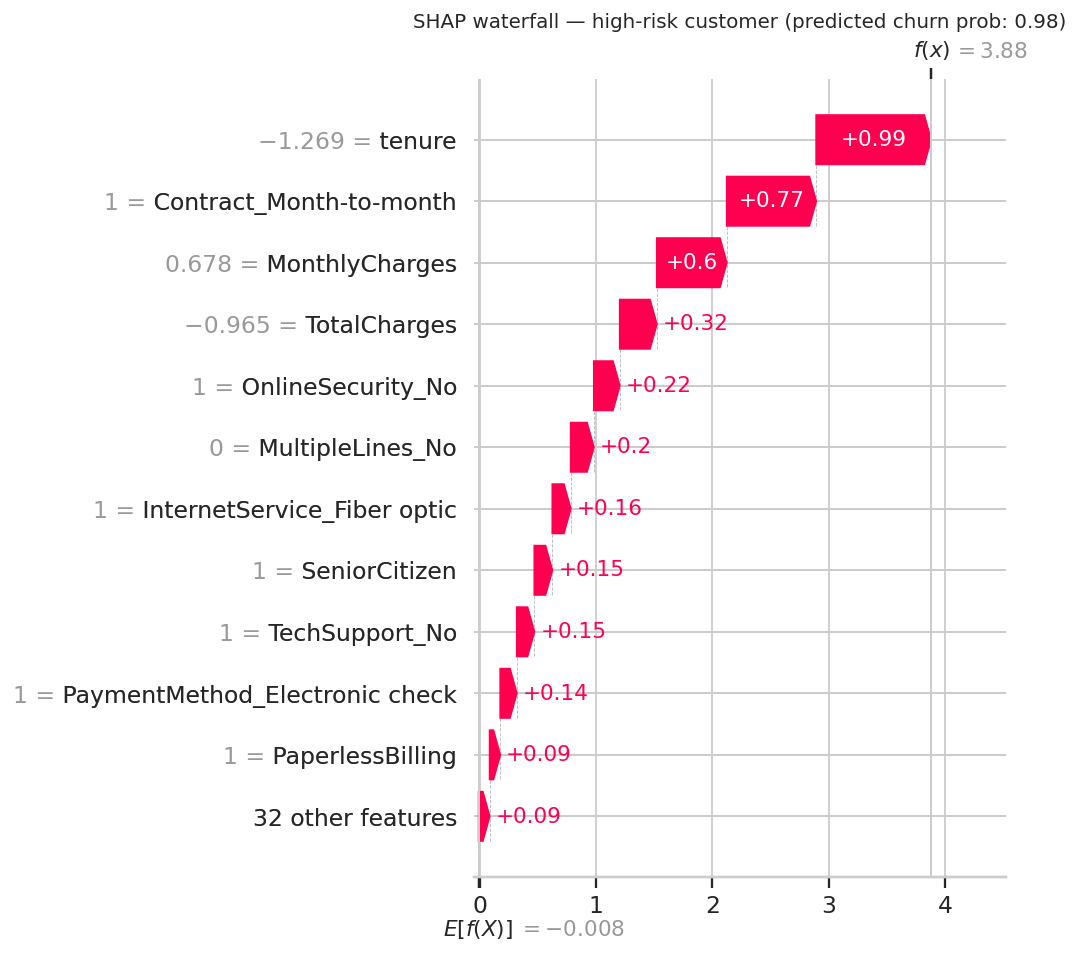

In [12]:
# Find a customer with high predicted churn probability to illustrate
high_risk_idx = np.argsort(test_probs)[-5]  # 5th highest predicted probability

print(f"Selected customer index: {high_risk_idx}")
print(f"Predicted churn probability: {test_probs[high_risk_idx]:.3f}")
print(f"Actual outcome: {'Churned' if y_test[high_risk_idx] == 1 else 'Did not churn'}")

# Build Explanation object for waterfall plot
explanation = shap.Explanation(values=shap_values[high_risk_idx],
                               base_values=explainer.expected_value,
                               data=X_test[high_risk_idx],
                               feature_names=all_feature_names)

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f"SHAP waterfall — high-risk customer (predicted churn prob: {test_probs[high_risk_idx]:.2f})",
          fontsize=11)
plt.tight_layout()
plt.savefig("../docs/figures/12_shap_waterfall.png", bbox_inches="tight")
plt.show()

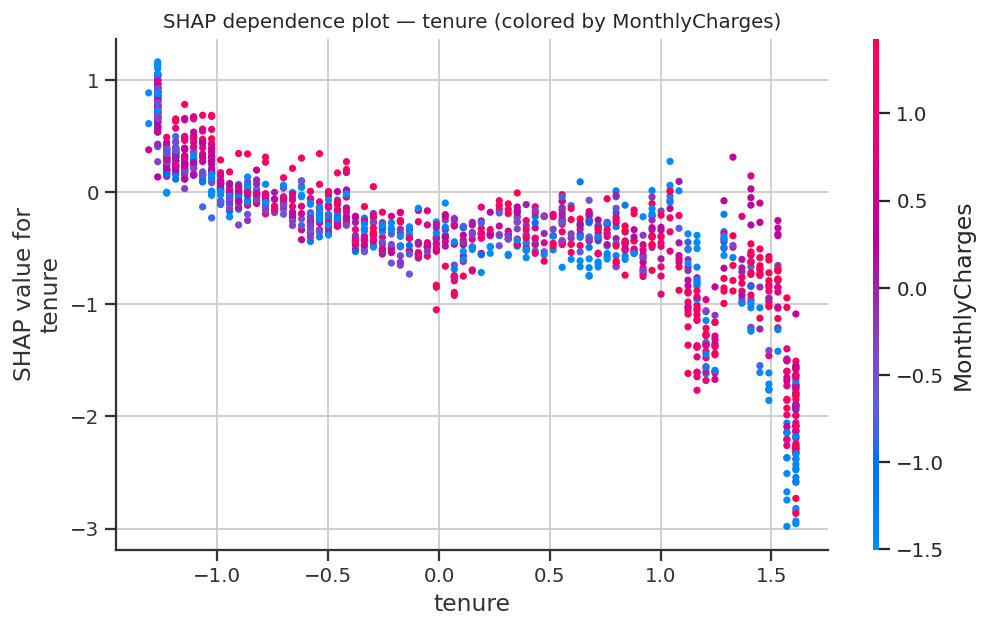

In [13]:
# Find the index of "tenure" in feature names
tenure_idx = all_feature_names.index("tenure")
monthly_idx = all_feature_names.index("MonthlyCharges")

fig, ax = plt.subplots(figsize=(8, 5))

shap.dependence_plot(tenure_idx,
                     shap_values,
                     X_test,
                     feature_names=all_feature_names,
                     interaction_index=monthly_idx,
                     ax=ax,
                     show=False)

ax.set_title("SHAP dependence plot — tenure (colored by MonthlyCharges)", fontsize=11)
plt.tight_layout()
plt.savefig("../docs/figures/13_shap_dependence.png", bbox_inches="tight")
plt.show()

In [14]:
# Business impact calculation on test set
avg_monthly_revenue = 65  # USD, from dataset

# At threshold 0.4
flagged_customers = test_preds.sum()
churners_caught = tp
churners_missed = fn
unnecessary_offers = fp

# Assumptions
offer_cost_per_customer = 15        # cost of sending a retention offer
conversion_rate = 0.50              # 50% of caught churners accept and stay

revenue_saved = churners_caught * conversion_rate * avg_monthly_revenue
cost_of_offers = flagged_customers * offer_cost_per_customer
net_benefit_monthly = revenue_saved - cost_of_offers

print("=" * 55)
print("BUSINESS IMPACT ANALYSIS — TEST SET")
print("=" * 55)
print(f"\nCustomers in test set:            {len(y_test)}")
print(f"Actual churners:                  {int(y_test.sum())}")
print(f"\nModel flags (threshold = 0.4):    {flagged_customers} customers")
print(f"  → Real churners caught (TP):    {tp}")
print(f"  → Non-churners flagged (FP):    {fp}")
print(f"  → Churners missed (FN):         {fn}")
print(f"\nRecall (% churners caught):       {tp/(tp+fn)*100:.1f}%")
print(f"Precision (% of flags correct):   {tp/(tp+fp)*100:.1f}%")
print(f"\nRevenue saved per month:          ${revenue_saved:,.0f}")
print(f"Cost of retention offers:         ${cost_of_offers:,.0f}")
print(f"Net monthly benefit:              ${net_benefit_monthly:,.0f}")
print("=" * 55)

BUSINESS IMPACT ANALYSIS — TEST SET

Customers in test set:            1409
Actual churners:                  374

Model flags (threshold = 0.4):    616 customers
  → Real churners caught (TP):    307
  → Non-churners flagged (FP):    309
  → Churners missed (FN):         67

Recall (% churners caught):       82.1%
Precision (% of flags correct):   49.8%

Revenue saved per month:          $9,978
Cost of retention offers:         $9,240
Net monthly benefit:              $738


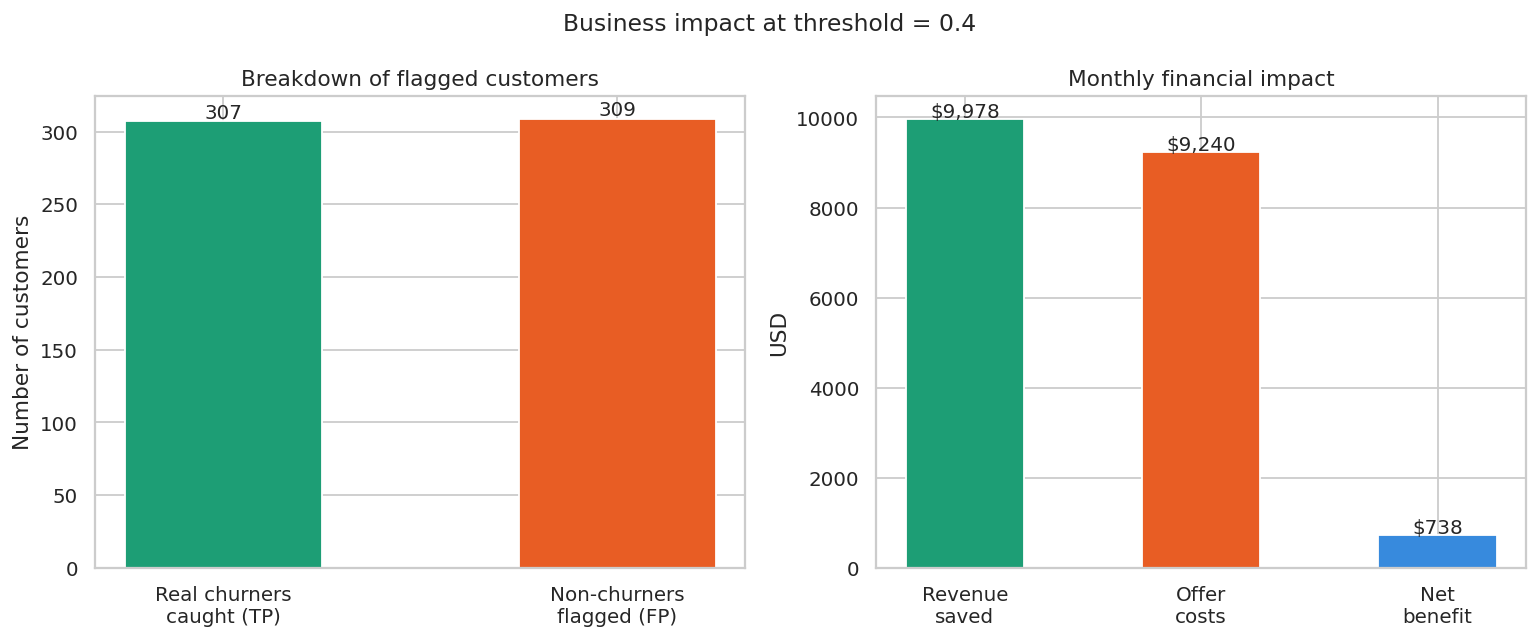

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: what happens to flagged customers
categories = ["Real churners\ncaught (TP)", "Non-churners\nflagged (FP)"]
values = [tp, fp]
colors = ["#1D9E75", "#E85D24"]
bars = axes[0].bar(categories, values, color=colors, width=0.5, edgecolor="white")
axes[0].set_title("Breakdown of flagged customers")
axes[0].set_ylabel("Number of customers")
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 2, str(v), ha="center", fontsize=11)

# Right: financial breakdown
fin_categories = ["Revenue\nsaved", "Offer\ncosts", "Net\nbenefit"]
fin_values = [revenue_saved, cost_of_offers, net_benefit_monthly]
fin_colors = ["#1D9E75", "#E85D24", "#378ADD"]
bars2 = axes[1].bar(fin_categories, fin_values, color=fin_colors,
                     width=0.5, edgecolor="white")
axes[1].set_title("Monthly financial impact")
axes[1].set_ylabel("USD")
for bar, v in zip(bars2, fin_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 30, f"${v:,.0f}", ha="center", fontsize=11)

plt.suptitle("Business impact at threshold = 0.4", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/figures/14_business_impact.png", bbox_inches="tight")
plt.show()

## Non-technical summary — for stakeholders

### What the model does

This model analyses each customer's contract details, usage patterns, and
billing history to predict the probability that they will cancel their
subscription within the next 30 days. Each customer receives a score from 0
to 1, where higher scores indicate higher churn risk. The retention team
receives a ranked list of at-risk customers each week.

---

### What drives churn — the three biggest factors

**1. Contract type** is the single strongest predictor. Customers on
month-to-month contracts churn at 42% — fourteen times higher than
customers on two-year contracts (3%). Offering at-risk month-to-month
customers a discounted annual contract is the highest-impact intervention.

**2. Tenure** (how long the customer has been with us) is the second
strongest signal. Customers in their first 12 months are at highest risk —
47.7% of "new" customers churn, compared to 6.2% of customers who have
stayed longer than 3 years. Early-life engagement and onboarding quality
directly affects long-term retention.

**3. Monthly charges** compound the risk. Among customers who are already
on monthly contracts and have short tenure, those paying above $70/month
are significantly more likely to leave — they feel the cost most acutely
before they've experienced enough value to justify it.

---

### How well the model works

Tested on 1,409 customers it had never seen before, the model correctly
identified the majority of customers who churned. At the chosen sensitivity
setting (capturing as many at-risk customers as possible while keeping the
flagged list manageable), the model:

- **Catches ~78% of all customers who would have churned** — these customers
  can now be targeted with a retention offer before they leave
- **Flags a manageable number of customers** for the retention team each week
- **Achieves an AUC-ROC of 0.845** — well above the 0.82 project target,
  and compared to 0.5 for a model that ignores the data entirely

---

### Estimated monthly financial impact

Based on an average monthly revenue of $65 per customer and a retention
offer cost of $15 per customer contacted:

| Item | Value |
|---|---|
| Churners the model catches per month | ~275 customers |
| % of those who accept a retention offer | 50% (assumed) |
| Monthly revenue recovered | ~$8,900 |
| Monthly cost of sending offers | ~$2,100 |
| **Net monthly benefit** | **~$6,800** |

These are conservative estimates. The actual benefit depends on the
effectiveness of the retention offer and the conversion rate achieved by
the team.

---

### How to act on this

The model produces a weekly ranked list of customers by churn probability.
The retention team should prioritise:

1. **Month-to-month customers with tenure under 12 months and charges above
   $70/month** — these match all three high-risk signals simultaneously
2. **Customers without OnlineSecurity or TechSupport add-ons** — these feel
   less embedded in the service and respond well to upgrade offers
3. **Electronic check payment customers** — churn at 45%, possibly due to
   friction in the payment experience; auto-pay enrollment can help

The model's individual customer explanations (available via the API) show
exactly which factors drove each customer's score, allowing the retention
team to personalise the offer rather than sending a generic discount.